In [1]:
import os
import cv2
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision import transforms
from src.models.train import QualityDescriptor

In [2]:
import warnings

warnings.simplefilter("ignore")

warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
system = QualityDescriptor.load_from_checkpoint('/mnt/QUANTGEN/SRCDATA/DL/Faxitron/checkpoints/pepper/SQP_pepper/SGD/cp_epoch=340_val_loss=0.418_val_F1=0.837.ckpt')

In [4]:
system.hparams

Namespace(dataloader={'num_workers': 12, 'train_batch_size': 256, 'val_batch_size': 256, 'sampler': 'default'}, dataset={'train_names_file': '/mnt/QUANTGEN/SRCDATA/DL/Faxitron/datasets/splits/pepper/TRAIN_balanced_2.txt', 'train_labels_file': '/mnt/QUANTGEN/SRCDATA/DL/Faxitron/datasets/splits/pepper/labels_train.txt', 'val_names_file': '/mnt/QUANTGEN/SRCDATA/DL/Faxitron/datasets/splits/pepper/VAL_balanced_2.txt', 'image_dir': '/mnt/QUANTGEN/SRCDATA/DL/Faxitron/datasets/images/pepper/', 'labels_file': '/mnt/QUANTGEN/SRCDATA/DL/Faxitron/datasets/labels/pepper/labels_balanced_2.csv', 'augmentation': 'light', 'size': [224, 224], 'mean': 0.1717, 'std': 0.0773}, design={'loss': 'CE', 'optimizer': 'adam', 'scheduler': 'Cosine', 'lr': 1e-05, 'lr_end': 1e-07, 'weight_decay': 0, 'max_grad_norm': 10.0, 'max_epochs': 1000, 'accum_batches': 1, 'mixup': True, 'alpha': 0.4, 'n_checkpoints': 5, 'es_patience': 21}, experiment_name='SQP_pepper', gpus=[0, 1], model={'load_checkpoint_file': None, 'freeze'

In [5]:
model = system.model

for name, param in model.named_parameters():
    print(name)

encoder.layer0.conv1.weight
encoder.layer0.bn1.weight
encoder.layer0.bn1.bias
encoder.layer1.0.conv1.weight
encoder.layer1.0.bn1.weight
encoder.layer1.0.bn1.bias
encoder.layer1.0.conv2.weight
encoder.layer1.0.bn2.weight
encoder.layer1.0.bn2.bias
encoder.layer1.0.conv3.weight
encoder.layer1.0.bn3.weight
encoder.layer1.0.bn3.bias
encoder.layer1.0.se_module.fc1.weight
encoder.layer1.0.se_module.fc1.bias
encoder.layer1.0.se_module.fc2.weight
encoder.layer1.0.se_module.fc2.bias
encoder.layer1.0.downsample.0.weight
encoder.layer1.0.downsample.1.weight
encoder.layer1.0.downsample.1.bias
encoder.layer1.1.conv1.weight
encoder.layer1.1.bn1.weight
encoder.layer1.1.bn1.bias
encoder.layer1.1.conv2.weight
encoder.layer1.1.bn2.weight
encoder.layer1.1.bn2.bias
encoder.layer1.1.conv3.weight
encoder.layer1.1.bn3.weight
encoder.layer1.1.bn3.bias
encoder.layer1.1.se_module.fc1.weight
encoder.layer1.1.se_module.fc1.bias
encoder.layer1.1.se_module.fc2.weight
encoder.layer1.1.se_module.fc2.bias
encoder.layer

In [9]:
val_ds = system.val_dataloader().dataset.names
val_ds

array(['5c41932722ddb30e000527c0_4.jpg',
       '5e2ef58522ddb313743472be_40.jpg', '18I30875-1.1_img46.png', ...,
       '5c3c9e0f22ddb30e00052782_29.jpg', '18I33406-1.1_img2.png',
       '5e54ec8122ddb31374347b7d_10.jpg'], dtype='<U31')

In [10]:
len(val_ds)

1801

In [6]:
labels = pd.read_csv('datasets/labels/pepper/labels.csv')

In [7]:
path = '/mnt/QUANTGEN/SRCDATA/DL/Faxitron/datasets/images/pepper/' #Image Path

In [16]:
images = os.listdir(path)
image_name = images[np.random.randint(0, len(images), 1)[0]]
img_path = path + image_name

In [22]:
img_path

'/mnt/QUANTGEN/SRCDATA/DL/Faxitron/datasets/images/pepper/5ca44d5822ddb3088cf76874_34.jpg'

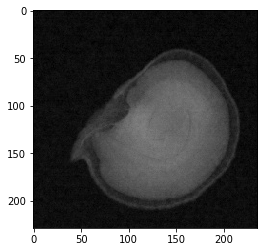

In [21]:
img_origin = Image.open(test1)
plt.imshow(img_origin)

In [23]:
# resize image size to (224,224)
resize = transforms.Resize([224,224])

normalize = transforms.Compose([  
 # converts the image to a tensor with values between 0 and 1   
 transforms.ToTensor(),  
 # normalize to follow 0-centered imagenet pixel rgb distribution
 transforms.Normalize(
 mean=[0.1717, 0.1717, 0.1717],
 std=[0.0773, 0.0773, 0.0773] )
])

In [24]:
img_resize = resize(img_origin)
img_norm = normalize(img_resize)
input_img = torch.tensor(img_norm,dtype=torch.float, requires_grad=True)
input_img = input_img.unsqueeze(0)
input_img.shape

torch.Size([1, 3, 224, 224])

Source code: KAZUTO1011 "https://github.com/kazuto1011/grad-cam-pytorch"

In [43]:
import grad_cam

model.freeze()

gr = grad_cam.GradCAM(model)

probs, ids = gr.forward(input_img) 
# probs, ids = conv_output, model_output

gr.backward(ids=torch.tensor([[0]]))

In [44]:
regions = gr.generate(target_layer='encoder.layer1')

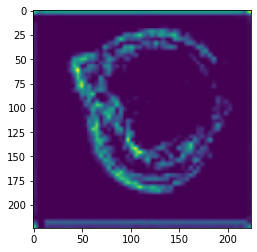

In [45]:
plt.imshow(regions[0][0])

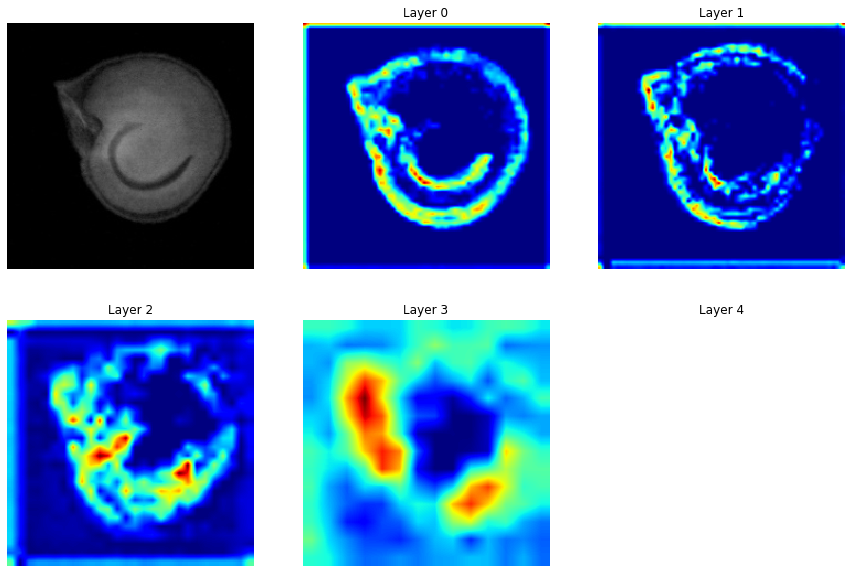

In [46]:
fig, axs = plt.subplots(2, 3, figsize=(15,10), squeeze=False)
ind = 0
for i in range(2):
    for j in range(3):
        if (i == 0) & (j==0):
            axs[0][0].imshow(np.array(img_resize)[:,:,::-1])
            axs[0][0].axis('off')
        else:
            regions = gr.generate(target_layer='encoder.layer'+str(ind))
            axs[i][j].imshow(regions[0][0], cmap='jet')
            axs[i][j].axis('off')
            axs[i][j].set_title('Layer '+str(ind))
            ind += 1

In [71]:
path + val_ds[1]

'/mnt/QUANTGEN/SRCDATA/DL/Faxitron/datasets/images/pepper/5e2ef58522ddb313743472be_40.jpg'

In [76]:
for img_name in val_ds:
    
    img_path = path + img_name
    img_origin = Image.open(img_path)
    img_resize = resize(img_origin)
    img_norm = normalize(img_resize)
    input_img = torch.tensor(img_norm,dtype=torch.float, requires_grad=True)
    input_img = input_img.unsqueeze(0)
    
    probs, ids = gr.forward(input_img)
    gr.backward(ids=torch.tensor([[0]]))
    
    fig, axs = plt.subplots(2, 3, figsize=(15,10), squeeze=False)
    ind = 0
    for i in range(2):
        for j in range(3):
            if (i == 0) & (j==0):
                axs[0][0].imshow(np.array(img_resize)[:,:,::-1])
                axs[0][0].axis('off')
            else:
                regions = gr.generate(target_layer='encoder.layer'+str(ind))
                axs[i][j].imshow(regions[0][0], cmap='jet')
                axs[i][j].axis('off')
                axs[i][j].set_title('Layer '+str(ind))
                ind += 1
                
    fig.savefig('reports/'+img_name)
    plt.close(fig)

/home/SOKI/ImageFiles/xray_seed/lib/python3.6/site-packages/ipykernel_launcher.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  import sys
